# Лабораторная работа №3. Вариант №18. Задание 2

2. Для любого заданного столбца данных (кроме первого) и любых 12-ти последовательных строчек из массива постройте интерполяционный полином Лагранжа, выведите его график на сетке с шагом `h` по оси `X – 0.1` вместе с исходными точками. Значение `999.9` в массиве означает отсутствие достоверных данных и должно быть исключено из анализа.

Подключение библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

Получение данных из файла. Заносим в переменную `headers` заголовки столбцов, а в `values` соответственно значения.

In [ ]:
clear_data = np.loadtxt(
    "18_Архангельск.csv", delimiter=",", dtype=str, encoding="utf-8-sig"
)

headers = clear_data[0]
values = clear_data[1:].astype(float)

headers

array(['Год', 'янв', 'фев', 'мар', 'апр', 'май', 'июн', 'июл', 'авг',
       'сен', 'окт', 'ноя', 'дек', 'средняя'], dtype='<U7')

Функция для отбора данных из таблицы данных.

Нам нужно взять информацию из столбцов, где нет значения «999.9». Поэтому мы сделаем так, чтобы строки с этим значением не учитывались.

In [ ]:
def clear_cols(
    array: np.ndarray, col: int | list[int] = None, error: float | int | list = 999.9
) -> list[float] | np.ndarray:
    """Очистка колонок данных от вредных данных.

    :param array: Двумерный список данных
    :type array: np.ndarray
    :param col: Кортеж индексов выбираемых колонок, defaults to None
    :type col: int | list[int], optional
    :param error: Значения ячеек, которые нужно не учитывать и пропускать, defaults to 999.9
    :type error: float | int | list, optional
    :return: Двумерный список, со строками без вредных ячеек
    :rtype: list[float] | np.ndarray
    """
    if col is None:
        col = list(range(array.shape[1]))
    elif isinstance(col, int):
        col = [col]

    if isinstance(error, (float, int)):
        error = [error]

    # Создаем маску индексов строк, которые не имеют error значений
    mask = np.ones(len(array), dtype=bool)
    for c in col:
        for err in error:
            mask &= array[:, c] != err

    # Создаем список по маске и изменяем положение его
    # т.е. Сделать колонки строками
    result = array[mask][:, col].T

    
    if len(col) == 1:
        return result[0]
    else:
        return result


## Функция интерполяции Лагранжа
$$L(x) = \sum_{i=0}^{n} y_i \cdot l_i(x), \quad \{x_i, \,y_i\}$$
$$l_i(x) = \prod_{i=0, \, j = i}^{n} \frac{x-x_j}{x_i - x_j}= \frac{x-x_0}{x_1 - x_0} \cdot \frac{x - x_{i-1}}{x_i - x_{i-1}} \cdot \dots$$
$$l_i(x_i) = 1$$
$$l_i(x_j) = 0, \qquad j \neq i$$

In [4]:
def lagrange_interpolation(
    x: float, x_data: list[float] | np.ndarray, y_data: list[float] | np.ndarray
) -> float:
    if len(set(x_data)) != len(x_data):
        raise ValueError(
            "X содержит дублирующиеся значения. Все точки должны быть уникальными."
        )

    n = len(x_data)

    result = 0.0
    for i in range(n):
        y_i = y_data[i]
        l_i = 1.0
        for j in range(n):
            if i == j:
                continue
            x_i, x_j = x_data[i], x_data[j]
            l_i *= (x - x_j) / (x_i - x_j)
        result += y_i * l_i
    return result

Получаем очищенные данные из необходимых столбцов. Пусть это будет *год* и *январь*.

In [5]:
cols = (0, 1)

x_data, y_data = clear_cols(values, cols)

start = 0
end = start + 12

y_data, x_data = y_data[start:end], x_data[start:end]

print(f"{x_data=}")
print(f"{y_data=}")

x_data=array([1814., 1815., 1816., 1817., 1818., 1819., 1820., 1821., 1822.,
       1823., 1824., 1825.])
y_data=array([-24.6, -11.7,  -8.2,  -8.7, -10.1,  -8.3, -21.7, -13.9, -11.9,
       -16.1, -17.3,  -7.8])


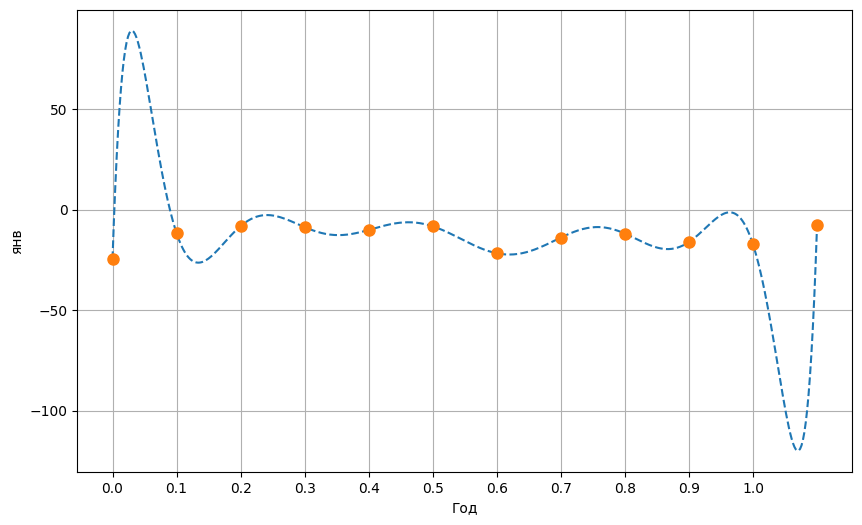

In [7]:
x_smooth = np.linspace(min(x_data), max(x_data), 500)
y_smooth = [lagrange_interpolation(x, x_data, y_data) for x in x_smooth]

plt.figure(figsize=(10, 6))
ax = plt.gca()
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, color="black")

plt.plot(x_smooth, y_smooth, "--")
plt.plot(x_data, y_data, "o", markersize=8)
plt.xticks(np.arange(x_data[0], x_data[-1], 1), [i / 10 for i in range(x_data.shape[0]-1)])

plt.xlabel(headers[cols[0]])
plt.ylabel(headers[cols[1]])
plt.grid(True)
plt.show()